# Book Recommender Project

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).

Books API from [openlibrary](https://openlibrary.org/developers/api).

Developed by: Bryan Calderon

#### **NLP**

* Loading packages and dataset

In [52]:
import requests
import pandas as pd
import time
import re

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pickle
import os
import nltk

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [53]:
df_nlp = pd.read_csv("data/books_with_clusters_pca.csv")

In [54]:
# Selecting text columns
text_columns = [
    "title",
    "author",
    "genres",
    "description",
    "cluster_label"]

In [55]:
# Creating a conbines text variable
df_nlp["combined_text"] = (
    df_nlp["title"] + " " +
    df_nlp["author"] + " " +
    df_nlp["genres"] + " " +
    df_nlp["description"] + " " +
    df_nlp["cluster_label"])

In [56]:
# Cleaning and preparing text
def clean_text(text):
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [57]:
df_nlp["clean_text"] = df_nlp["combined_text"].apply(clean_text) # returning cleaning text variable

In [58]:
df_nlp["text_length"] = df_nlp["clean_text"].apply(lambda x: len(x.split()))

df_nlp["text_length"].describe()

count    1229.000000
mean      114.728234
std        70.298104
min        21.000000
25%        69.000000
50%        83.000000
75%       150.000000
max       458.000000
Name: text_length, dtype: float64

In [59]:
df_nlp

,source_year,title,author,average_rating,ratings_count,reviews_count,description,genres,pages,publisher,...,genre_nonfiction,genre_fiction_in_english,genre_magic,cluster,cluster_label,pca_1,pca_2,combined_text,clean_text,text_length
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,"crime novel, English Civil War, mires, tors, t...",375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",...,0,0,0,1,General genre fiction,-1.934800,0.919645,The Hound of the Baskervilles Arthur Conan Doy...,the hound of the baskervilles arthur conan doy...,90
1,1900,The Classic Tale of the Velveteen Rabbit,Margery Williams Bianco,4.125000,40,0,The Classic Tale of the Velveteen Rabbit Marge...,"Toys, Fiction, Children's fiction, Toys, ficti...",375,"Nosy Crow Ltd, Joe Books Inc., Independently P...",...,0,0,0,3,Children’s & juvenile fantasy,-2.604513,-2.230634,The Classic Tale of the Velveteen Rabbit Marge...,the classic tale of the velveteen rabbit marge...,74
2,1900,No country for old men,Cormac McCarthy,4.111111,36,0,No country for old men Cormac McCarthy Fiction...,"Fiction, Drug traffic, Sheriffs, Treasure-trov...",375,"GPO ED RANDOM HOUSE MONDADORI, MacMillan, Bran...",...,0,0,0,1,General genre fiction,-1.434532,-0.000240,No country for old men Cormac McCarthy Fiction...,no country for old men cormac mccarthy fiction...,67
3,1900,The Prophet,Kahlil Gibran,4.321429,56,0,"The Prophet Kahlil Gibran Poetry, Classics, Li...","Poetry, Classics, Literature & Fiction, Religion",375,"Patmos-Verlag, Patmos, Ballantine Books, Pmapu...",...,0,0,0,1,General genre fiction,-1.012640,0.346625,"The Prophet Kahlil Gibran Poetry, Classics, Li...",the prophet kahlil gibran poetry classics lite...,32
4,1900,The Railway Children,Edith Nesbit,3.965517,29,0,The Railway Children Edith Nesbit Brothers and...,"Brothers and sisters, Children's stories, Clas...",375,"HV Publishign, a division of Homepage Ventures...",...,0,0,0,3,Children’s & juvenile fantasy,-2.910596,-1.176072,The Railway Children Edith Nesbit Brothers and...,the railway children edith nesbit brothers and...,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,2024,The Housemaid is Watching,Freida McFadden,3.850000,1131225,78371,“You must be our new neighbors!” Mrs. Lowell g...,"Thriller, Mystery, Audiobook, Fiction, Mystery...",387,Unknown,...,0,0,0,2,"Thriller, mystery & horror",1.782544,2.821573,The Housemaid is Watching Freida McFadden Thri...,the housemaid is watching freida mcfadden thri...,336
1225,2024,Quicksilver,Callie Hart,4.310000,952918,109568,This #1 New York Times bestseller is a highly ...,"Fantasy, Romantasy, Romance, Audiobook, Fae, F...",624,Unknown,...,0,0,0,4,"Romance, fantasy & young adult",2.976769,-1.136944,"Quicksilver Callie Hart Fantasy, Romantasy, Ro...",quicksilver callie hart fantasy romantasy roma...,345
1226,2024,The Teacher,Freida McFadden,3.890000,1084462,101711,"A mind-bending, psychological thriller from Fr...","Thriller, Audiobook, Mystery, Mystery Thriller...",379,Unknown,...,0,0,0,2,"Thriller, mystery & horror",1.965654,2.799823,"The Teacher Freida McFadden Thriller, Audioboo...",the teacher freida mcfadden thriller audiobook...,173
1227,2024,Funny Story,Emily Henry,4.180000,1378310,171293,"A shimmering, joyful new novel about a pair of...","Romance, Audiobook, Fiction, Contemporary, Boo...",395,Unknown,...,0,0,0,4,"Romance, fantasy & young adult",3.708749,-0.286716,"Funny Story Emily Henry Romance, Audiobook, Fi...",funny story emily henry romance audiobook fict...,280


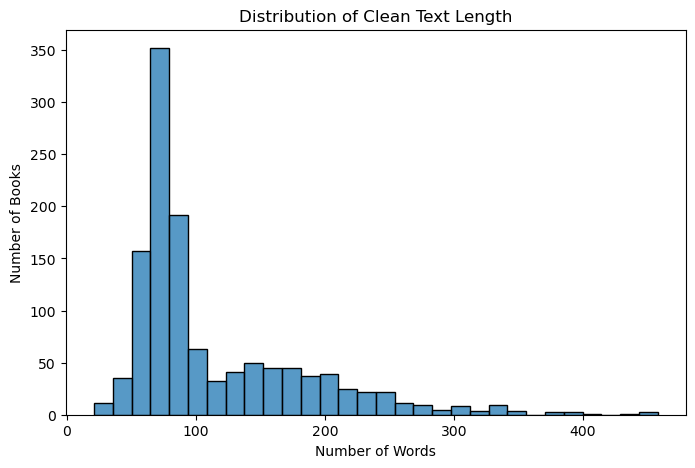

In [60]:
plt.figure(figsize=(8, 5))
sns.histplot(df_nlp["text_length"], bins=30)
plt.title("Distribution of Clean Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Books")
plt.show()

Most books have clean text descriptions between 50 and 100 words, while a smaller number of books contain longer descriptions. This indicates that the dataset has enough textual content for TF-IDF vectorization, although the amount of text varies across books.

#### TF-IDF vectorization

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    "book", "books", "story", "stories", "novel", "novels",
    "fiction", "general", "literature", "english",
    "edition", "author", "read", "reader", "readers"]))  # Words that can make aquard the models


mod1 = TfidfVectorizer(
    stop_words=custom_stop_words,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85)

In [63]:
mod1_matrix = mod1.fit_transform(df_nlp["clean_text"])

mod1_matrix.shape

(1229, 5000)

In [64]:
feature_names = mod1.get_feature_names_out()

mod1_scores = np.asarray(mod1_matrix.mean(axis=0)).ravel()

df_terms = pd.DataFrame({
    "term": feature_names,
    "score": mod1_scores
}).sort_values("score", ascending=False)

df_terms.head(30)

,term,score
1520,fantasy,0.030432
3030,mystery,0.029907
3922,science,0.027878
779,children,0.027262
2501,juvenile,0.025647
3823,romance,0.022997
2087,historical,0.022788
2690,life,0.020243
4983,young,0.019663
169,american,0.018077


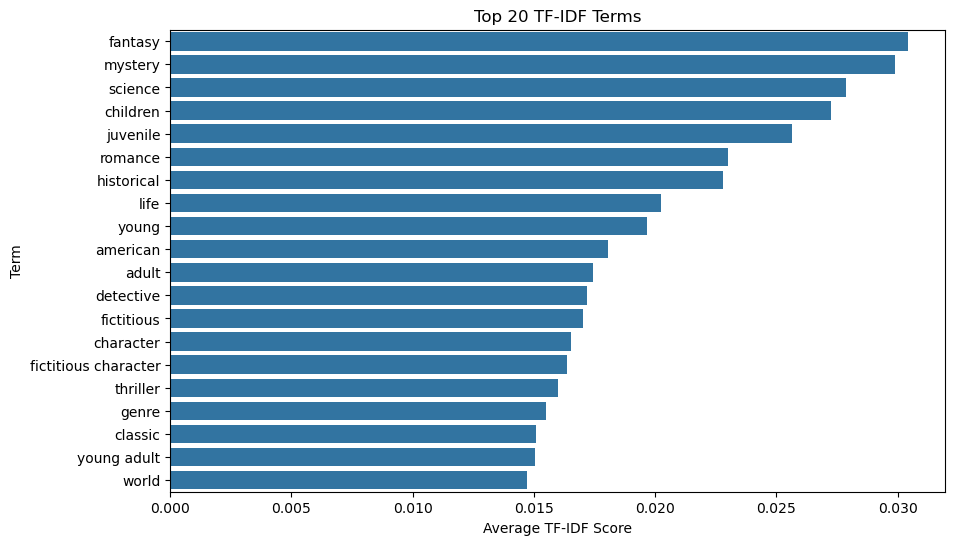

In [65]:
top_terms = df_terms.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms, x="score", y="term")
plt.title("Top 20 TF-IDF Terms")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.show()

In [66]:
cosine_sim = cosine_similarity(mod1_matrix)

cosine_sim.shape

(1229, 1229)

### Recommendation function

In [67]:
def recommend_books(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(
        similarity_scores, 
        key=lambda x: x[1], 
        reverse=True
    )
    
    # Skip the first book because it is the same book
    similarity_scores = similarity_scores[1:n+1]
    
    book_indices = [i[0] for i in similarity_scores]
    scores = [i[1] for i in similarity_scores]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"
    ]].copy()
    
    recommendations["similarity_score"] = scores
    
    return recommendations

In [68]:
df_nlp["title"].sample(10, random_state=42)

548     The Stars My Destination
1125             Big Little Lies
244               Tod in Venedig
552              Giovanni's Room
1163                      Verity
1048         Water for Elephants
809                         Cujo
589                 Deathworld 1
101       The Emerald City of Oz
128                    El Dorado
Name: title, dtype: object

In [69]:
recommend_books("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Thriller, mystery & horror",Goodreads Popular by Year,0.204239
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Thriller, mystery & horror",Goodreads Popular by Year,0.199590
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Thriller, mystery & horror",Goodreads Popular by Year,0.196313
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Thriller, mystery & horror",Goodreads Popular by Year,0.186776
824,A Is for Alibi,Sue Grafton,1982,3.86,193648,"Mystery, Fiction, Crime, Mystery Thriller, Aud...","Thriller, mystery & horror",Goodreads Popular by Year,0.179345


In [70]:
recommend_books(df_nlp["title"].iloc[0], df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score
262,The Case-Book of Sherlock Holmes,Arthur Conan Doyle,1927,4.548387,31,"Fiction, English Detective and mystery stories...",General genre fiction,Open Library API,0.567606
129,The Poison Belt,Arthur Conan Doyle,1913,4.500000,4,"Professor Challenger (Fictitious character), F...",General genre fiction,Open Library API,0.296777
161,His Last Bow [8 stories],Arthur Conan Doyle,1917,4.133333,30,"short stories, Detective and mystery fiction, ...",General genre fiction,Open Library API,0.261896
6,The Lost World,Arthur Conan Doyle,1900,4.045454,44,"Adventure stories, Atlantis, Dinosaurs, Discov...",General genre fiction,Open Library API,0.254169
378,The confidential agent,Graham Greene,1939,3.250000,8,"Fiction, Spy Thrillers, Mystery and detective ...",General genre fiction,Open Library API,0.236590


#### Improved version considring clustering

In [71]:
def recommend_books_same_cluster(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    book_cluster = df.loc[idx, "cluster"]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    
    # Remove same book
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx
    ]
    
    # Add cluster preference
    adjusted_scores = []
    
    for i, score in similarity_scores:
        same_cluster_bonus = 0.10 if df.loc[i, "cluster"] == book_cluster else 0
        adjusted_score = score + same_cluster_bonus
        adjusted_scores.append((i, adjusted_score, score))
    
    adjusted_scores = sorted(
        adjusted_scores, 
        key=lambda x: x[1], 
        reverse=True
    )
    
    top_books = adjusted_scores[:n]
    
    book_indices = [i[0] for i in top_books]
    final_scores = [i[1] for i in top_books]
    original_scores = [i[2] for i in top_books]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"
    ]].copy()
    
    recommendations["similarity_score"] = original_scores
    recommendations["final_score"] = final_scores
    
    return recommendations

In [72]:
recommend_books_same_cluster("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score,final_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Thriller, mystery & horror",Goodreads Popular by Year,0.204239,0.304239
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Thriller, mystery & horror",Goodreads Popular by Year,0.199590,0.299590
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Thriller, mystery & horror",Goodreads Popular by Year,0.196313,0.296313
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Thriller, mystery & horror",Goodreads Popular by Year,0.186776,0.286776
824,A Is for Alibi,Sue Grafton,1982,3.86,193648,"Mystery, Fiction, Crime, Mystery Thriller, Aud...","Thriller, mystery & horror",Goodreads Popular by Year,0.179345,0.279345


In [73]:
def recommend_books_weighted(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx
    ]
    
    recommendations = []
    
    for i, similarity in similarity_scores:
        rating_scaled = df.loc[i, "average_rating"] / 5
        popularity_scaled = np.log1p(df.loc[i, "ratings_count"]) / np.log1p(df["ratings_count"].max())
        
        final_score = (
            0.70 * similarity +
            0.20 * rating_scaled +
            0.10 * popularity_scaled
        )
        
        recommendations.append((i, similarity, final_score))
    
    recommendations = sorted(
        recommendations,
        key=lambda x: x[2],
        reverse=True
    )
    
    top_books = recommendations[:n]
    
    book_indices = [i[0] for i in top_books]
    
    results = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"
    ]].copy()
    
    results["similarity_score"] = [i[1] for i in top_books]
    results["final_score"] = [i[2] for i in top_books]
    
    return results

In [74]:
recommend_books_weighted("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score,final_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Thriller, mystery & horror",Goodreads Popular by Year,0.204239,0.401062
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Thriller, mystery & horror",Goodreads Popular by Year,0.186776,0.394632
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Thriller, mystery & horror",Goodreads Popular by Year,0.199590,0.392364
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Thriller, mystery & horror",Goodreads Popular by Year,0.196313,0.380669
1170,A Good Girl's Guide to Murder,Holly Jackson,2019,4.28,1857089,"Mystery, Thriller, Young Adult, Mystery Thrill...","Thriller, mystery & horror",Goodreads Popular by Year,0.159361,0.371474


The NLP model powers the recommendation system. It compares books based on their title, author, genre, description, and cluster label. Using TF-IDF and cosine similarity, the system finds books with similar textual content. We also added rating and popularity weights to recommend books that are not only similar, but also well-rated and relevant.

### VADER

In [77]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [81]:
df_sentiment = df_nlp.copy()

In [78]:
def get_vader_scores(text):
    if pd.isna(text):
        text = ""
    
    scores = analyzer.polarity_scores(str(text))
    
    return pd.Series({
        "sentiment_neg": scores["neg"],
        "sentiment_neu": scores["neu"],
        "sentiment_pos": scores["pos"],
        "sentiment_compound": scores["compound"] })

In [82]:
analyzer = SentimentIntensityAnalyzer()

In [83]:
sentiment_scores = df_sentiment["description"].apply(get_vader_scores)

df_sentiment = pd.concat(
    [df_sentiment, sentiment_scores],
    axis=1
)

In [84]:
def sentiment_label(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [85]:
df_sentiment["description_sentiment"] = df_sentiment["sentiment_compound"].apply(sentiment_label)

In [86]:
df_sentiment[[
    "title",
    "description",
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_pos",
    "sentiment_compound",
    "description_sentiment"
]].head()

,title,description,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,description_sentiment
0,The Hound of the Baskervilles,The Hound of the Baskervilles Arthur Conan Doy...,0.131,0.829,0.041,-0.7269,Negative
1,The Classic Tale of the Velveteen Rabbit,The Classic Tale of the Velveteen Rabbit Marge...,0.000,0.931,0.069,0.4404,Positive
2,No country for old men,No country for old men Cormac McCarthy Fiction...,0.053,0.894,0.053,0.0000,Neutral
3,The Prophet,"The Prophet Kahlil Gibran Poetry, Classics, Li...",0.000,1.000,0.000,0.0000,Neutral
4,The Railway Children,The Railway Children Edith Nesbit Brothers and...,0.078,0.862,0.060,0.0258,Neutral


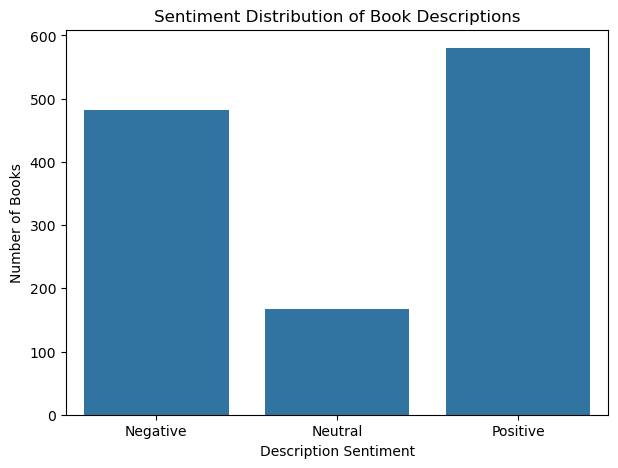

In [88]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_sentiment,
    x="description_sentiment",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Sentiment Distribution of Book Descriptions")
plt.xlabel("Description Sentiment")
plt.ylabel("Number of Books")
plt.show()

In [92]:
sentiment_by_cluster = (
    df_sentiment
    .groupby(["cluster_label", "description_sentiment"])
    .size()
    .reset_index(name="book_count")
)

sentiment_by_cluster

,cluster_label,description_sentiment,book_count
0,Children’s & juvenile fantasy,Negative,50
1,Children’s & juvenile fantasy,Neutral,48
2,Children’s & juvenile fantasy,Positive,102
3,General genre fiction,Negative,251
4,General genre fiction,Neutral,107
5,General genre fiction,Positive,187
6,Historical & classic fiction,Negative,28
7,Historical & classic fiction,Neutral,4
8,Historical & classic fiction,Positive,87
9,Nonfiction & history,Negative,16


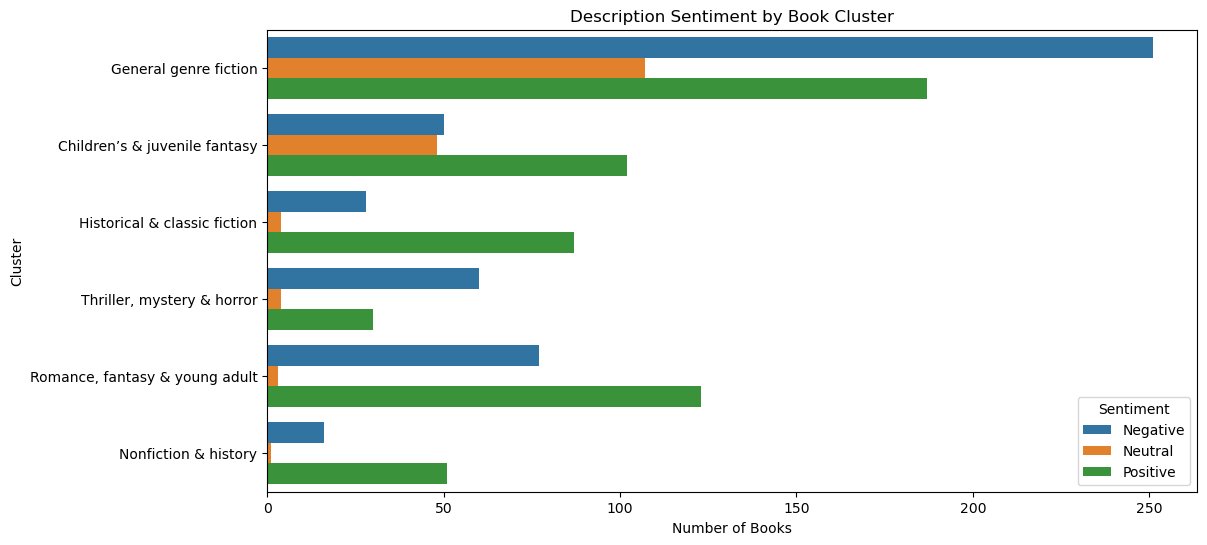

In [93]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_sentiment,
    y="cluster_label",
    hue="description_sentiment",
    hue_order=["Negative", "Neutral", "Positive"]
)

plt.title("Description Sentiment by Book Cluster")
plt.xlabel("Number of Books")
plt.ylabel("Cluster")
plt.legend(title="Sentiment")
plt.show()

In [94]:
df_sentiment["combined_text"] = (
    df_sentiment["title"].fillna("") + " " +
    df_sentiment["author"].fillna("") + " " +
    df_sentiment["genres"].fillna("") + " " +
    df_sentiment["description"].fillna("") + " " +
    df_sentiment["cluster_label"].fillna("") + " " +
    df_sentiment["description_sentiment"].fillna("")
)

In [95]:
def recommend_books_with_sentiment(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    input_sentiment = df.loc[idx, "description_sentiment"]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx
    ]
    
    adjusted_scores = []
    
    for i, score in similarity_scores:
        sentiment_bonus = 0.05 if df.loc[i, "description_sentiment"] == input_sentiment else 0
        final_score = score + sentiment_bonus
        adjusted_scores.append((i, score, final_score))
    
    adjusted_scores = sorted(
        adjusted_scores,
        key=lambda x: x[2],
        reverse=True
    )
    
    top_books = adjusted_scores[:n]
    book_indices = [i[0] for i in top_books]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "description_sentiment"
    ]].copy()
    
    recommendations["similarity_score"] = [i[1] for i in top_books]
    recommendations["final_score"] = [i[2] for i in top_books]
    
    return recommendations

In [98]:
recommend_books_with_sentiment("The Silent Patient", df_sentiment, cosine_sim, n=5)

,title,author,average_rating,ratings_count,genres,cluster_label,description_sentiment,similarity_score,final_score
1203,The Housemaid,Freida McFadden,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Thriller, mystery & horror",Positive,0.186776,0.236776
894,Jurassic Park,Michael Crichton,4.14,1081696,"Science Fiction, Fiction, Thriller, Horror, Fa...","Thriller, mystery & horror",Positive,0.167266,0.217266
1114,The Husband's Secret,Liane Moriarty,3.94,734612,"Fiction, Book Club, Mystery, Contemporary, Chi...","Thriller, mystery & horror",Positive,0.166581,0.216581
1224,The Housemaid is Watching,Freida McFadden,3.85,1131225,"Thriller, Mystery, Audiobook, Fiction, Mystery...","Thriller, mystery & horror",Positive,0.162947,0.212947
1130,The Girl on the Train,Paula Hawkins,3.96,3345878,"Fiction, Mystery, Thriller, Book Club, Mystery...","Thriller, mystery & horror",Positive,0.162181,0.212181
